In [7]:
import pandas as pd

fund = pd.read_csv("../data/raw/01_fund_master.csv")
nav = pd.read_csv("../data/raw/02_nav_history.csv")
aum = pd.read_csv("../data/raw/03_aum_by_fund_house.csv")
sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")
category = pd.read_csv("../data/raw/05_category_inflows.csv")
folio = pd.read_csv("../data/raw/06_industry_folio_count.csv")
performance = pd.read_csv("../data/raw/07_scheme_performance.csv")
transactions = pd.read_csv("../data/raw/08_investor_transactions.csv")
portfolio = pd.read_csv("../data/raw/09_portfolio_holdings.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [8]:
print(fund.shape)
print(nav.shape)
print(transactions.shape)

(40, 15)
(46000, 3)
(32778, 13)


In [15]:
import pandas as pd
import plotly.express as px

In [16]:
import pandas as pd
import plotly.express as px

nav = pd.read_csv("../data/raw/02_nav_history.csv")

nav["date"] = pd.to_datetime(nav["date"])

sample = nav.groupby("amfi_code").head(200)

fig = px.line(
    sample,
    x="date",
    y="nav",
    color="amfi_code",
    title="NAV Trend Analysis"
)

fig.show(renderer="browser")

In [17]:
plt.savefig("../reports/chart_name.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

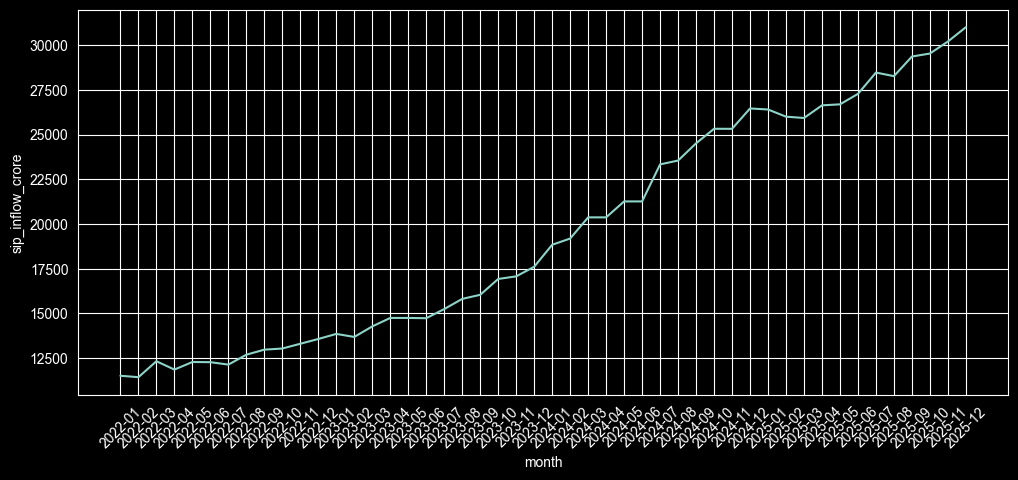

In [14]:
plt.figure(figsize=(12,5))

sns.lineplot(
    data=sip,
    x="month",
    y="sip_inflow_crore"
)

plt.xticks(rotation=45)
plt.show()

In [19]:
plt.savefig("../reports/chart_name.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [9]:
fund.head()

,amfi_code,fund_house,scheme_name,category,sub_category,plan,launch_date,benchmark,expense_ratio_pct,exit_load_pct,min_sip_amount,min_lumpsum_amount,fund_manager,risk_category,sebi_category_code
0,119551,SBI Mutual Fund,SBI Bluechip Fund - Regular Plan - Growth,Equity,Large Cap,Regular,2006-02-14,NIFTY 100 TRI,1.54,1.0,500,1000,Sohini Andani,Moderate,EC01
1,119552,SBI Mutual Fund,SBI Bluechip Fund - Direct Plan - Growth,Equity,Large Cap,Direct,2013-01-01,NIFTY 100 TRI,0.66,1.0,500,1000,Sohini Andani,Moderate,EC01
2,119598,SBI Mutual Fund,SBI Small Cap Fund - Regular Plan - Growth,Equity,Small Cap,Regular,2009-09-09,BSE 250 SmallCap TRI,1.43,1.0,500,1000,R. Srinivasan,Very High,EC03
3,119599,SBI Mutual Fund,SBI Small Cap Fund - Direct Plan - Growth,Equity,Small Cap,Direct,2013-01-01,BSE 250 SmallCap TRI,0.72,1.0,500,1000,R. Srinivasan,Very High,EC03
4,119120,SBI Mutual Fund,SBI Magnum Gilt Fund - Regular Plan - Growth,Debt,Gilt,Regular,2000-12-30,CRISIL Dynamic Gilt Index,0.77,0.0,500,1000,Dinesh Ahuja,Low,DC02


In [16]:
print(category.columns)

Index(['month', 'category', 'net_inflow_crore'], dtype='str')


In [23]:
print(category.columns.tolist())

['month', 'category', 'net_inflow_crore']


In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

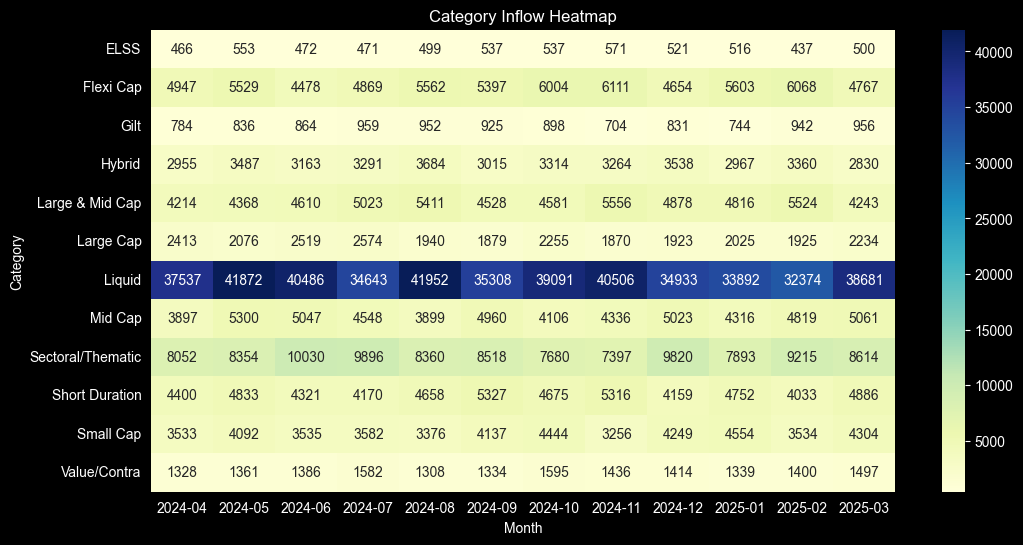

In [24]:
import seaborn as sns
import matplotlib.pyplot as plt

pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(12,6))
sns.heatmap(pivot, annot=True, fmt=".0f", cmap="YlGnBu")

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Category")

plt.show()

In [35]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

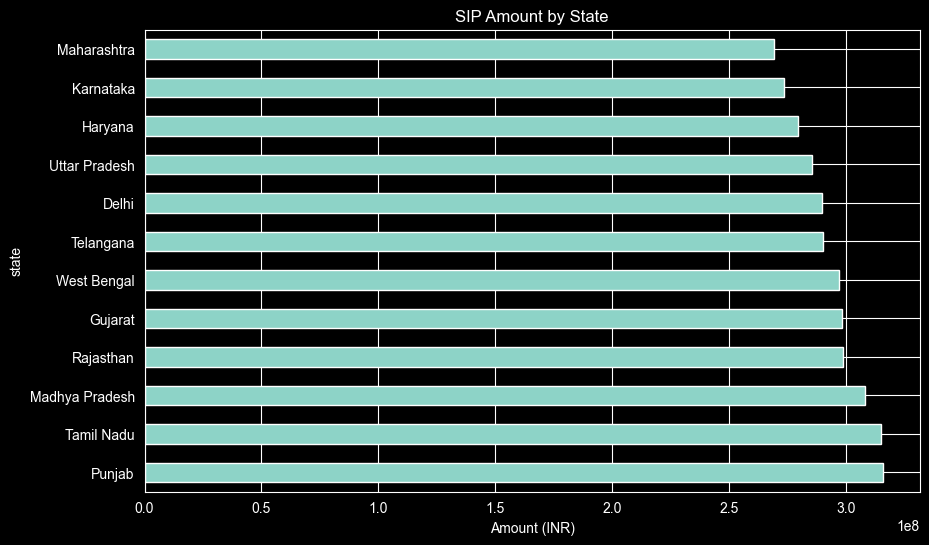

In [25]:
state_data = (
    transactions.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(10,6))
state_data.head(15).plot(kind="barh")

plt.title("SIP Amount by State")
plt.xlabel("Amount (INR)")plt.show()

In [34]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

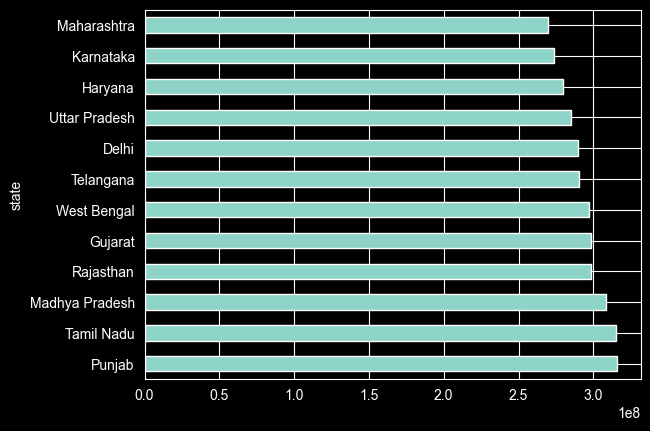

In [27]:
state_data = (
    transactions.groupby("state")
    ["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

state_data.plot(kind="barh")
plt.show()

In [33]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

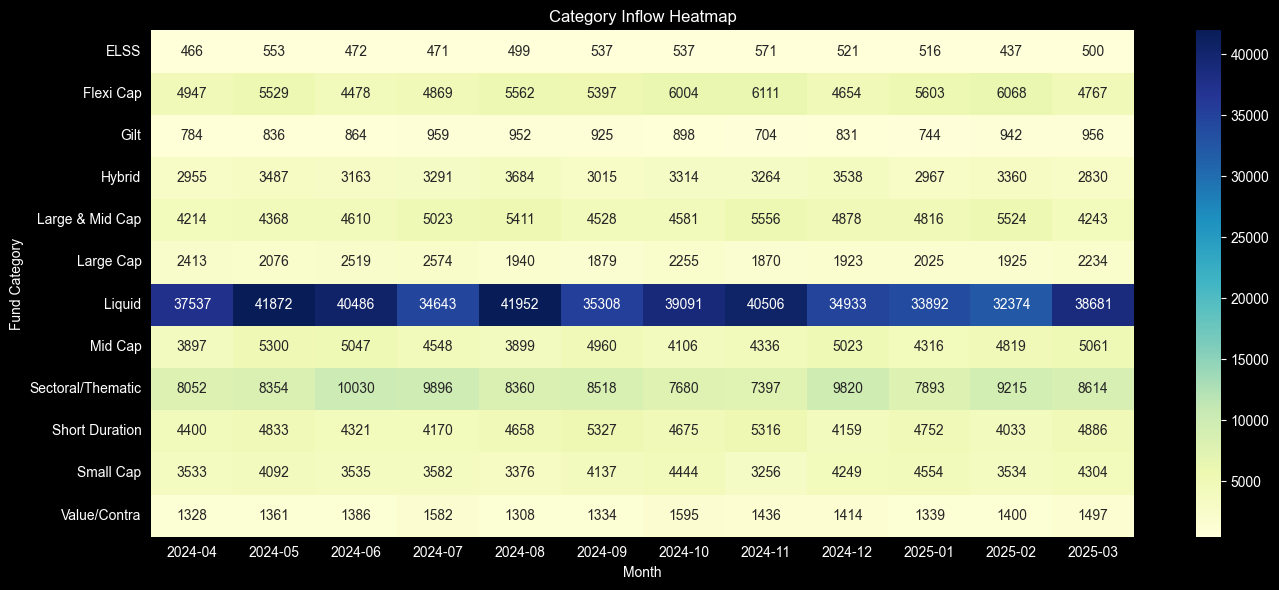

In [33]:

import seaborn as sns
import matplotlib.pyplot as plt

pivot = category.pivot_table(
    index="category",
    columns="month",
    values="net_inflow_crore",
    aggfunc="sum"
)

plt.figure(figsize=(14, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu"
)

plt.title("Category Inflow Heatmap")
plt.xlabel("Month")
plt.ylabel("Fund Category")

plt.tight_layout()
plt.show()

In [32]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

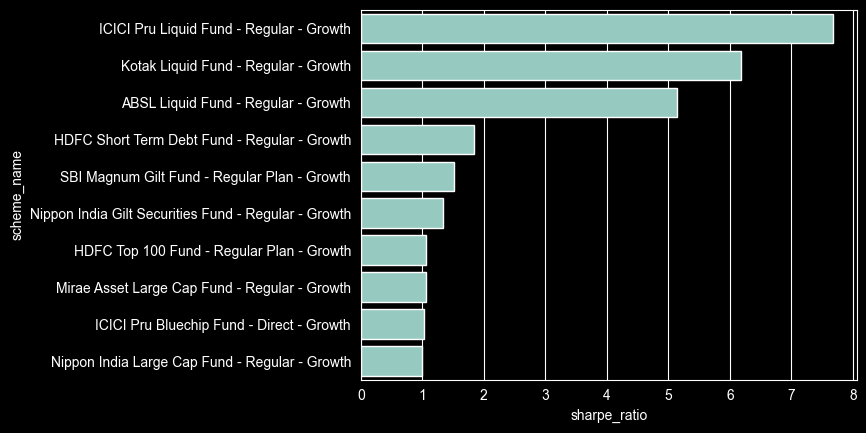

In [29]:
top10 = performance.nlargest(
    10,
    "sharpe_ratio"
)

sns.barplot(
    data=top10,
    x="sharpe_ratio",
    y="scheme_name"
)

plt.show()

In [31]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

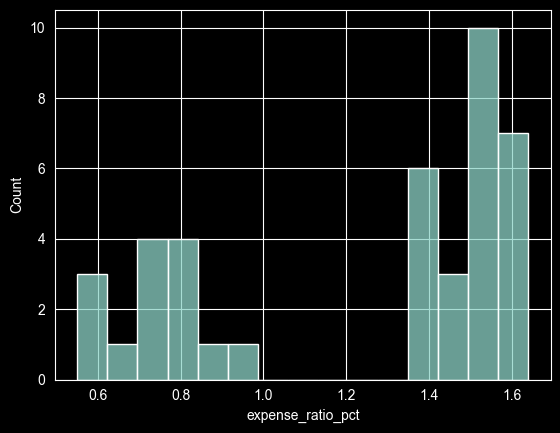

In [30]:
sns.histplot(
    performance["expense_ratio_pct"],
    bins=15
)

plt.show()

In [30]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

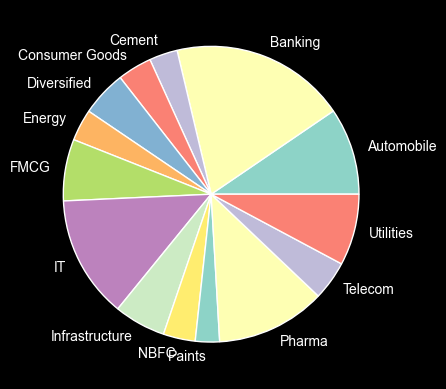

In [31]:
sector = (
    portfolio.groupby("sector")
    ["weight_pct"]
    .sum()
)

sector.plot(kind="pie")
plt.show()

In [29]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

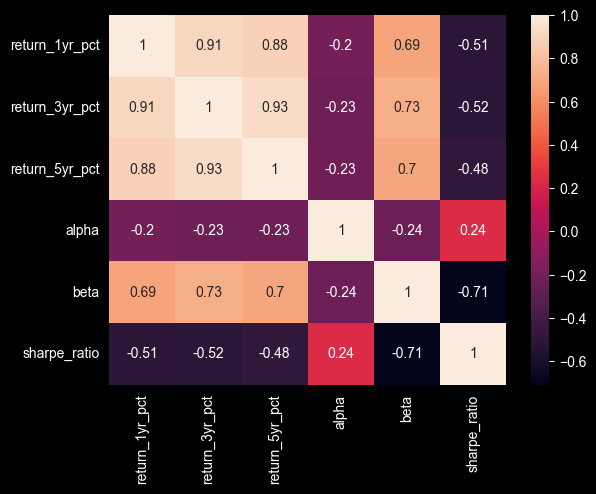

In [32]:
corr = performance[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio"
    ]
].corr()

sns.heatmap(
    corr,
    annot=True
)

plt.show()

In [28]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [36]:
print(folio.columns.tolist())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']


In [38]:
print(folio.columns.tolist())
print(folio.head())

['month', 'total_folios_crore', 'equity_folios_crore', 'debt_folios_crore', 'hybrid_folios_crore', 'others_folios_crore']
     month  total_folios_crore  equity_folios_crore  debt_folios_crore  \
0  2022-01               13.26                 9.28               1.86   
1  2022-04               13.91                 9.74               1.95   
2  2022-07               13.85                 9.69               1.94   
3  2022-10               14.12                 9.88               1.98   
4  2023-01               14.81                10.37               2.07   

   hybrid_folios_crore  others_folios_crore  
0                 0.80                 1.33  
1                 0.83                 1.39  
2                 0.83                 1.38  
3                 0.85                 1.41  
4                 0.89                 1.48  


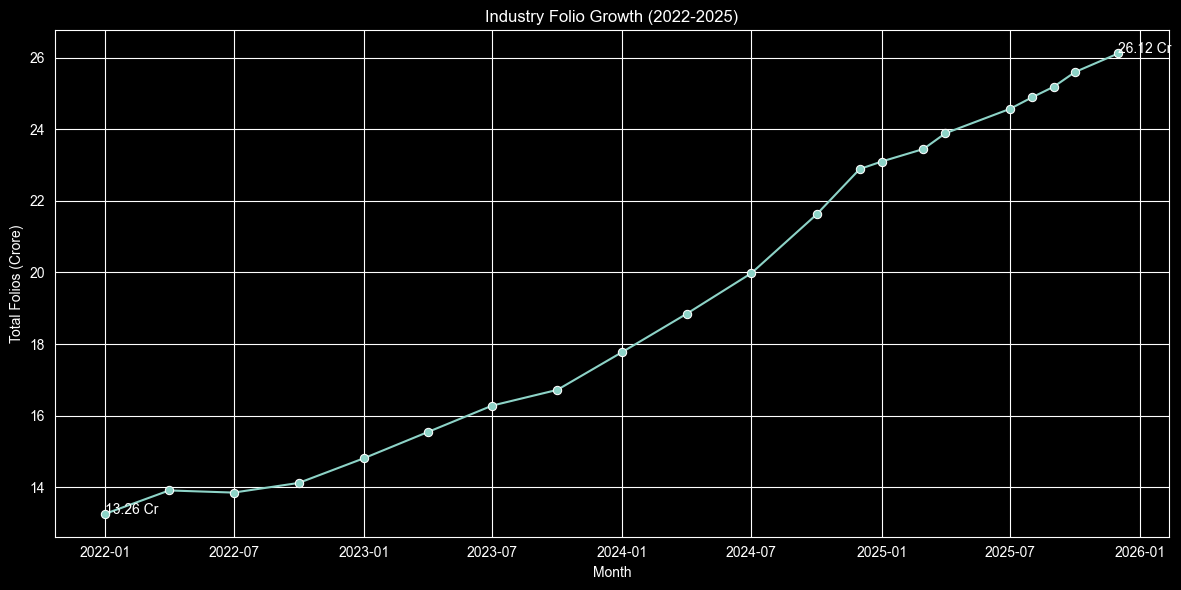

In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

folio["month"] = pd.to_datetime(folio["month"])

plt.figure(figsize=(12,6))

sns.lineplot(
    data=folio,
    x="month",
    y="total_folios_crore",
    marker="o"
)

plt.title("Industry Folio Growth (2022-2025)")
plt.xlabel("Month")
plt.ylabel("Total Folios (Crore)")

# Start milestone
plt.annotate(
    f"{folio['total_folios_crore'].iloc[0]} Cr",
    (folio["month"].iloc[0], folio["total_folios_crore"].iloc[0])
)

# End milestone
plt.annotate(
    f"{folio['total_folios_crore'].iloc[-1]} Cr",
    (folio["month"].iloc[-1], folio["total_folios_crore"].iloc[-1])
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [27]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

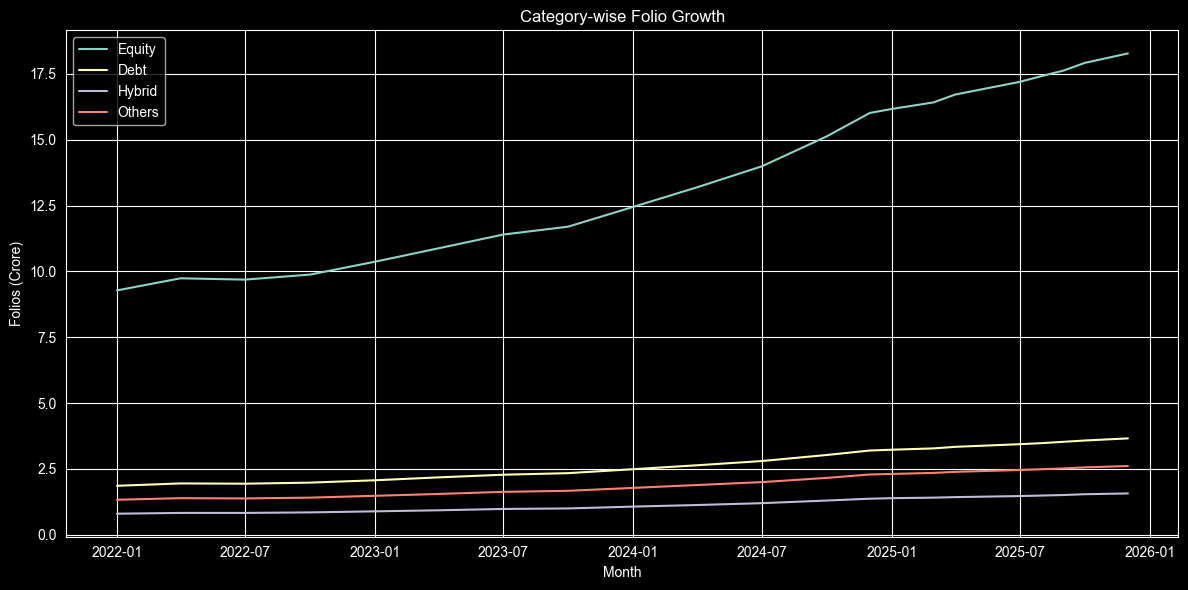

In [40]:
plt.figure(figsize=(12,6))

plt.plot(folio["month"], folio["equity_folios_crore"], label="Equity")
plt.plot(folio["month"], folio["debt_folios_crore"], label="Debt")
plt.plot(folio["month"], folio["hybrid_folios_crore"], label="Hybrid")
plt.plot(folio["month"], folio["others_folios_crore"], label="Others")

plt.title("Category-wise Folio Growth")
plt.xlabel("Month")
plt.ylabel("Folios (Crore)")
plt.legend()

plt.tight_layout()
plt.show()

In [26]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [7]:
plt.savefig("../reports/folio_growth.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [6]:
import matplotlib.pyplot as plt

In [36]:
plt.savefig("../reports/aum_growth.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [37]:
plt.savefig("../reports/category_heatmap.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [38]:
plt.savefig("../reports/state_distribution.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [39]:
plt.savefig("../reports/correlation_matrix.png", bbox_inches="tight")

<Figure size 640x480 with 0 Axes>

In [40]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(
    data=sip,
    x="month",
    y="sip_inflow_crore",
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xticks(rotation=45)

plt.savefig("../reports/sip_trend.png", bbox_inches="tight")
plt.show()

NameError: name 'sip' is not defined

<Figure size 1200x600 with 0 Axes>

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = performance[
    [
        "return_1yr_pct",
        "return_3yr_pct",
        "return_5yr_pct",
        "alpha",
        "beta",
        "sharpe_ratio"
    ]
].corr()

plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Performance Correlation Matrix")

plt.savefig("../reports/correlation_matrix.png", bbox_inches="tight")
plt.show()

NameError: name 'performance' is not defined

In [42]:
sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

sector.plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Sector Allocation")

plt.savefig("../reports/sector_allocation.png", bbox_inches="tight")
plt.show()

NameError: name 'portfolio' is not defined

In [43]:
import pandas as pd

sip = pd.read_csv("../data/raw/04_monthly_sip_inflows.csv")

print(sip.head())
print(sip.columns.tolist())

     month  sip_inflow_crore  active_sip_accounts_crore  \
0  2022-01             11517                       4.91   
1  2022-02             11438                       4.93   
2  2022-03             12328                       5.09   
3  2022-04             11863                       5.48   
4  2022-05             12286                       5.55   

   new_sip_accounts_lakh  sip_aum_lakh_crore  yoy_growth_pct  
0                   9.10                4.80             NaN  
1                   8.20                4.85             NaN  
2                  10.50                5.01             NaN  
3                   9.52                5.12             NaN  
4                   8.10                5.15             NaN  
['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


In [44]:
print(sip.columns.tolist())

['month', 'sip_inflow_crore', 'active_sip_accounts_crore', 'new_sip_accounts_lakh', 'sip_aum_lakh_crore', 'yoy_growth_pct']


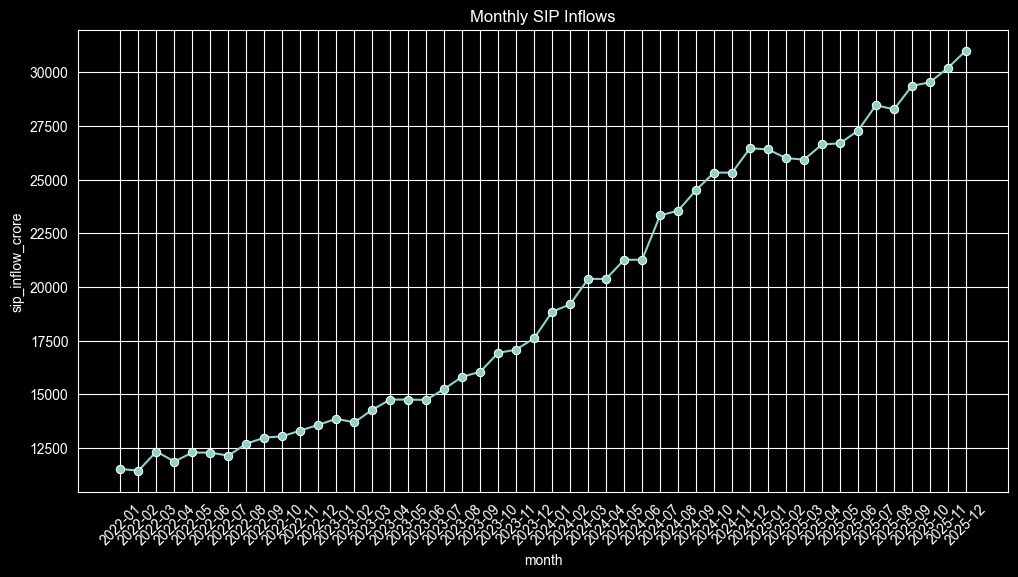

In [45]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))

sns.lineplot(
    data=sip,
    x="month",
    y="sip_inflow_crore",
    marker="o"
)

plt.title("Monthly SIP Inflows")
plt.xticks(rotation=45)

plt.savefig("../reports/sip_trend.png", bbox_inches="tight")
plt.show()

In [46]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = performance.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig("../reports/correlation_matrix.png",
            bbox_inches="tight")

plt.show()

NameError: name 'performance' is not defined

In [47]:
import pandas as pd

performance = pd.read_csv(
    "../data/raw/07_scheme_performance.csv"
)

print(performance.head())
print(performance.columns.tolist())

   amfi_code                                   scheme_name       fund_house  \
0     119551     SBI Bluechip Fund - Regular Plan - Growth  SBI Mutual Fund   
1     119552      SBI Bluechip Fund - Direct Plan - Growth  SBI Mutual Fund   
2     119598    SBI Small Cap Fund - Regular Plan - Growth  SBI Mutual Fund   
3     119599     SBI Small Cap Fund - Direct Plan - Growth  SBI Mutual Fund   
4     119120  SBI Magnum Gilt Fund - Regular Plan - Growth  SBI Mutual Fund   

    category     plan  return_1yr_pct  return_3yr_pct  return_5yr_pct  \
0  Large Cap  Regular           12.42           12.36           14.45   
1  Large Cap   Direct           15.25           11.30           14.23   
2  Small Cap  Regular           24.56           23.39           20.67   
3  Small Cap   Direct           20.59           23.14           21.82   
4       Gilt  Regular            5.34            6.07            5.43   

   benchmark_3yr_pct  alpha  beta  sharpe_ratio  sortino_ratio  \
0              11.49

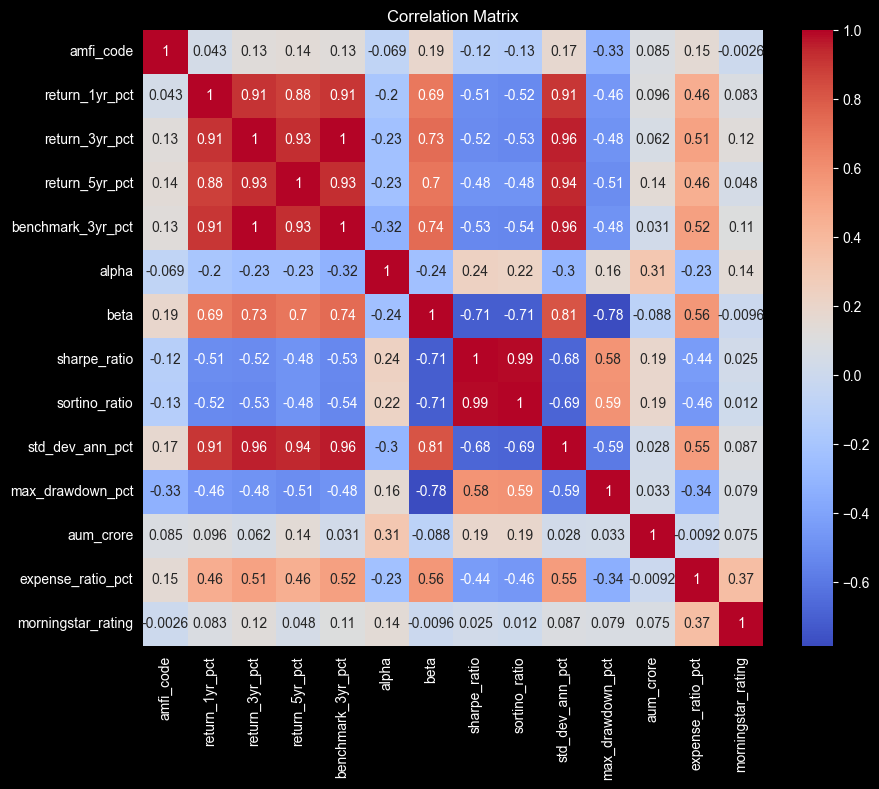

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = performance.corr(numeric_only=True)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.savefig(
    "../reports/correlation_matrix.png",
    bbox_inches="tight"
)

plt.show()

In [49]:
import pandas as pd

portfolio = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

print(portfolio.columns.tolist())

['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct', 'market_value_cr', 'current_price_inr', 'portfolio_date']


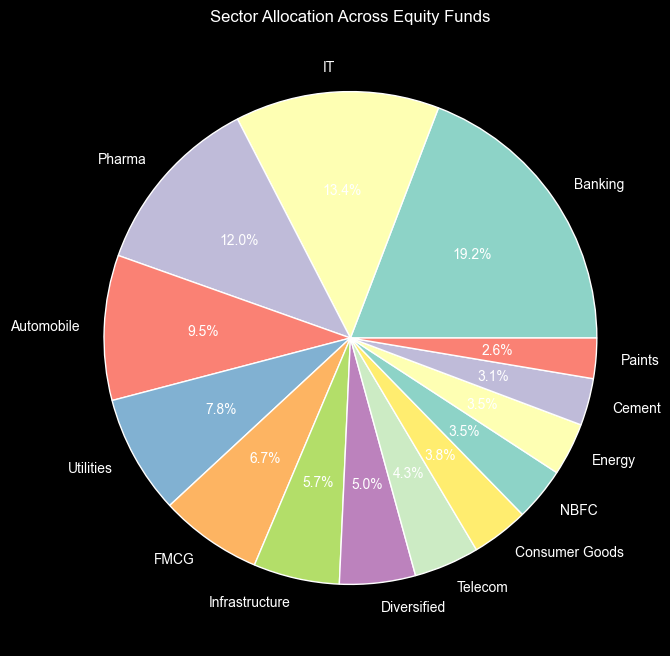

In [50]:
import matplotlib.pyplot as plt

sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8,8))

sector.plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.title("Sector Allocation Across Equity Funds")
plt.ylabel("")

plt.savefig(
    "../reports/sector_allocation.png",
    bbox_inches="tight"
)

plt.show()

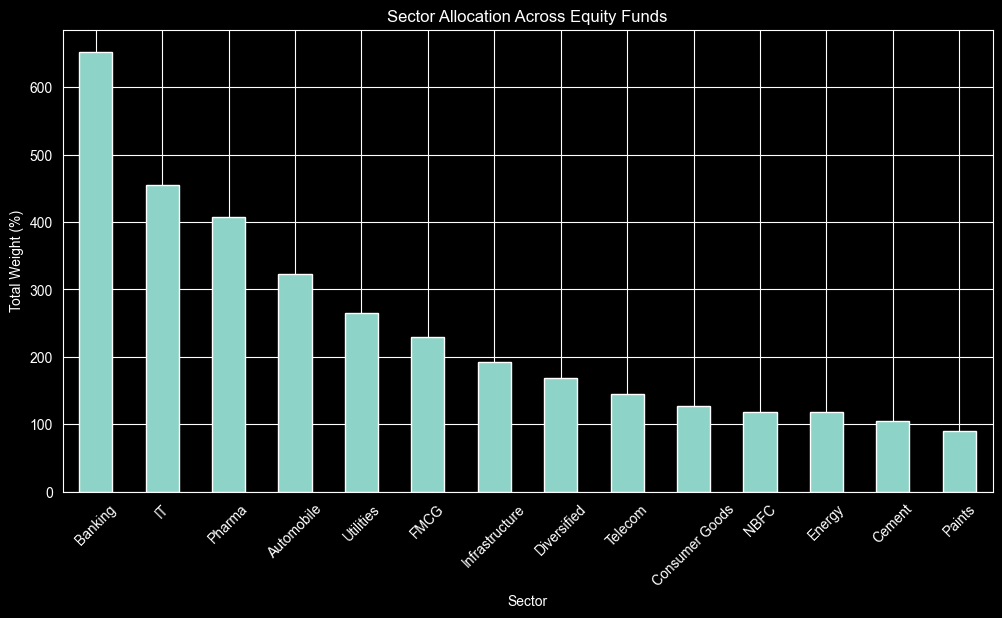

In [51]:
import matplotlib.pyplot as plt

sector = (
    portfolio.groupby("sector")["weight_pct"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))

sector.plot(kind="bar")

plt.title("Sector Allocation Across Equity Funds")
plt.xlabel("Sector")
plt.ylabel("Total Weight (%)")

plt.xticks(rotation=45)

plt.savefig(
    "../reports/sector_allocation.png",
    bbox_inches="tight"
)

plt.show()